# Predictive Modeling

Build models to predict game success based on features.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('../data/processed/cleaned_games.csv')
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DLC count,Supported languages,Windows,...,Publishers,Categories,Genres,owners_low,owners_high,owners_mid,high_owners,high_score,high_ccu,successful
0,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0 - 20000,0,0,5.24,0,['English'],True,...,['MangaGamer'],"['Single-player', 'Steam Trading Cards', 'Stea...",['Adventure'],0,20000,10000.0,False,False,False,False
1,1034400,Mystery Solitaire The Black Raven,2019-05-06,0 - 20000,0,0,4.99,0,"['English', 'French', 'German', 'Russian']",True,...,['8floor'],"['Single-player', 'Family Sharing']",['Casual'],0,20000,10000.0,False,False,False,False
2,3292190,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,0 - 20000,1,0,8.99,1,['Korean'],True,...,['유진게임즈'],"['Single-player', 'Steam Achievements', 'Famil...","['Casual', 'Indie', 'Simulation']",0,20000,10000.0,False,False,False,False
3,3631080,Maze Quest VR,2025-04-24,0 - 20000,0,0,4.99,0,['English'],True,...,['Reality Expanded LLC'],"['Single-player', 'VR Only', 'Steam Leaderboar...","['Action', 'Early Access']",0,20000,10000.0,False,False,False,False
4,1654170,Agony VR,2023-04-05,0 - 20000,0,0,13.99,0,"['English', 'French', 'Italian', 'German', 'Sp...",True,...,"['Ignibit', 'Madmind Studio']","['Single-player', 'Tracked Controller Support'...","['Action', 'Adventure']",0,20000,10000.0,False,False,False,False


In [3]:
# Prepare features for regression (predict owners_mid)
features = ['Price', 'Required age', 'Achievements', 'Windows', 'Mac', 'Linux']
# Add genre dummies (simplified, take first genre)
df['main_genre'] = df['Genres'].apply(lambda x: x[0] if isinstance(x, list) and x else 'Unknown')
genre_dummies = pd.get_dummies(df['main_genre'], prefix='genre')
X = pd.concat([df[features], genre_dummies], axis=1)
y = df['owners_mid']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print('Linear Regression R2:', r2_score(y_test, y_pred_lr))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression R2: 0.024673771323792337
RMSE: 1282603.6385419008


Random Forest R2: 0.009326093025950888
RMSE: 1292655.737193335


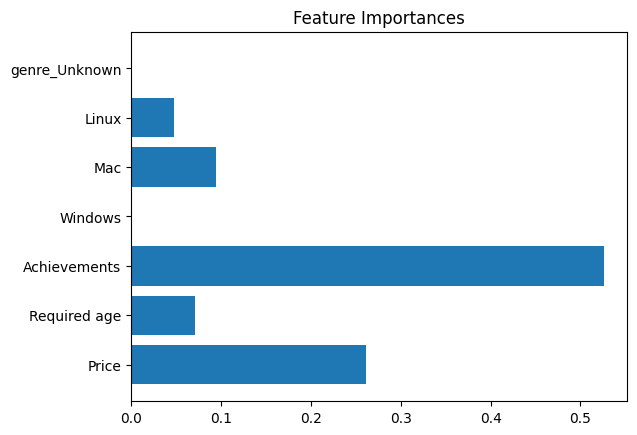

In [4]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest R2:', r2_score(y_test, y_pred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rf)))

# Feature importance
importances = rf.feature_importances_
feature_names = X.columns
plt.barh(feature_names, importances)
plt.title('Feature Importances')
plt.show()

In [5]:
# Classification for successful
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

y_class = df['successful']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)
print('Accuracy:', accuracy_score(y_test_c, y_pred_c))
print(classification_report(y_test_c, y_pred_c))

Accuracy: 1.0
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     20194

    accuracy                           1.00     20194
   macro avg       1.00      1.00      1.00     20194
weighted avg       1.00      1.00      1.00     20194



            owners_mid  User score     Price
cluster                                     
0         90817.131603    0.026307  5.202492
1         17727.272727    0.000000  9.774848
2        185948.636203    0.051435  5.766966


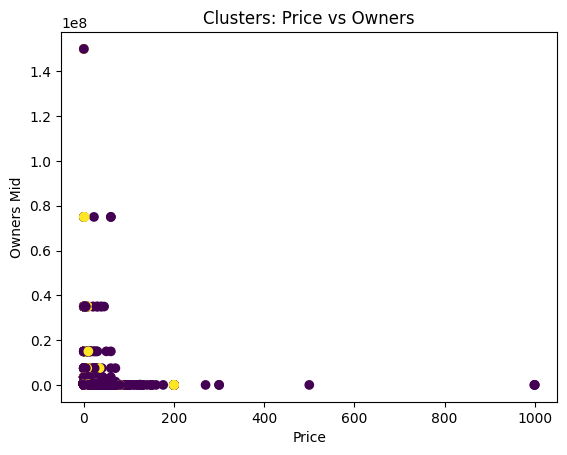

In [6]:
# Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters

# Analyze clusters
cluster_summary = df.groupby('cluster')[['owners_mid', 'User score', 'Price']].mean()
print(cluster_summary)

# Plot
plt.scatter(df['Price'], df['owners_mid'], c=clusters, cmap='viridis')
plt.xlabel('Price')
plt.ylabel('Owners Mid')
plt.title('Clusters: Price vs Owners')
plt.show()